# 05 · Save bands per index and overlay on the flux

Compute a band for several indices, save one JSON per index, then overlay
them on the optimized flux as asymmetric error bars.

In [2]:
import warnings; warnings.simplefilter('ignore')
from neutrino_analysis_band import NeutrinoAnalysis

a = NeutrinoAnalysis(background_scenario='flat', intervals='180',
                     GeV=0.32e16, solver='osqp', T=3)
a.optimize(a.data_vector)

# A few indices for a quick demo (real runs use many more).
for idx in [0, 20, 40, 80, 120]:
    a.find_and_save_band(
        idx, levels=(0.678, 0.954),
        num_pseudo_data=20, n_pseudo_edge=80,   # small/fast for the demo
        step=1.5, rel_tol=0.08, seed=42, verbose=True,
    )
print('saved to', a.bands_dir)

[band idx=0] v0=1.0448e+12 (phys), bracketing with step=1.5
  upper bracket: 2.6776e+13
  lower bracket: 6.9650e+11
  level 0.678: [9.2071e+11, 1.0488e+13] (phys)
  level 0.954: [8.3196e+11, 1.9267e+13] (phys)
Band saved as T3/scenario_bkg_flat/bands/band_bkgflat_idx000.json
[band idx=20] v0=9.1380e+11 (phys), bracketing with step=1.5
  upper bracket: 1.3707e+12
  lower bracket: 6.0920e+11
  level 0.678: [7.2768e+11, 1.0915e+12] (phys)
  level 0.954: [6.9172e+11, 1.2708e+12] (phys)
Band saved as T3/scenario_bkg_flat/bands/band_bkgflat_idx020.json
[band idx=40] v0=7.3634e+11 (phys), bracketing with step=1.5
  upper bracket: 1.1045e+12
  lower bracket: 4.9090e+11
  level 0.678: [5.8637e+11, 9.2528e+11] (phys)
  level 0.954: [5.2984e+11, 1.0240e+12] (phys)
Band saved as T3/scenario_bkg_flat/bands/band_bkgflat_idx040.json
[band idx=80] v0=4.4928e+11 (phys), bracketing with step=1.5
  upper bracket: 6.7393e+11
  lower bracket: 1.9968e+11
  level 0.678: [3.0731e+11, 6.2479e+11] (phys)
  leve

Plot saved as T3/scenario_bkg_flat/flux_with_bands_bkg_flat.pdf


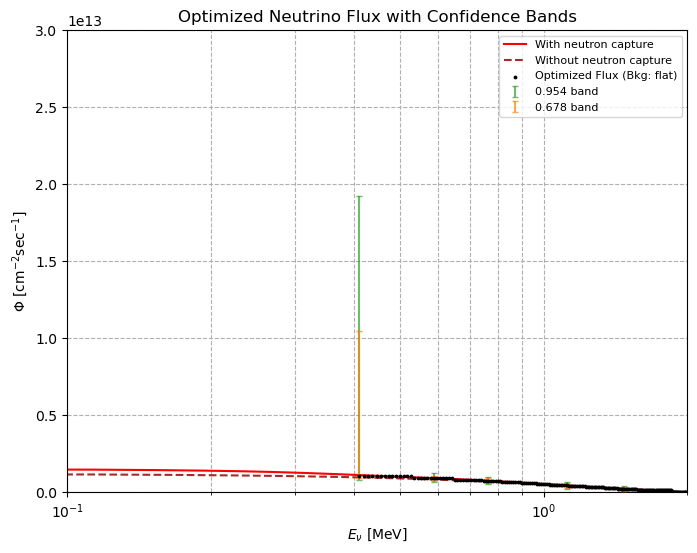

In [3]:
# Overlay the saved bands on the optimize result.
a.plot_flux_with_bands(f'{a.bands_dir}/band_*.json',
                       levels=(0.678, 0.954), ylim=(0, 3e13))
import matplotlib.pyplot as plt; plt.show()

`save_band` / `load_band` use plain JSON (human-readable). The band
centre is the saved `a.result.x[index]`, so it lines up exactly with the
scatter from the same `optimize` result.